# INR data-loss comparison

Compares data-fidelity criteria for the INR reconstruction from a fixed pretrained start, by
**convergence** (loss curve) and **quality** (MSE vs a near-optimal reference):
`l2_amplitude` (default), `l1_amplitude`, `smooth_l1_amplitude`, and `s3im_amplitude`
(stochastic structural similarity, shown to help INRs).

The loss is selected via `reconstruct(loss_type=...)`, which accepts a registered name or a
`DataCriterion` instance (to tune parameters, e.g. `AmplitudeS3IM(lambda_s3im=0.2)`). Object LR is
kept at **1e-3** (1e-2 did not help).

In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import quantem as em
from quantem.core import config
from quantem.core.ml import OptimizerParams, SchedulerParams
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectINR,
    ObjectPixelated,
    ProbePixelated,
    Ptychography,
    PtychographyDatasetRaster,
)
from quantem.diffractive_imaging.ptycho_losses import AmplitudeS3IM, AmplitudeSmoothL1

print(f"quantEM version: {em.__version__}")

GPU_ID = 2
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")

# Multi-GPU keeps per-GPU memory low at batch_size=125; set DEVICES="gpu" for a single device
# (use a smaller batch then). NOTE: s3im_amplitude is markedly slower than the others.
DEVICES = [0, 1, 2, 3]
BATCH_SIZE = 125

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
Using GPU cuda:2


In [3]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset = em.io.load(filepath)
good_recon = np.load("../../data/near_optimal_ducky_phase_cropped.npy")

PROBE_ENERGY = 80e3
PROBE_SEMIANGLE = 20
PROBE_DEFOCUS = 500
probe_params = {"energy": PROBE_ENERGY, "defocus": PROBE_DEFOCUS, "semiangle_cutoff": PROBE_SEMIANGLE}
r1 = slice(10, 110), slice(10, 110)
r2 = slice(220, 320), slice(220, 320)
detector_model = DetectorPixelated()

## Pixelated baseline (warm-starts the INR object + probe)

Calculated best fit rotation = 0 degrees.


Iter 150/150, Loss: 4.402e+00: 100%|██████████| 150/150 [00:09<00:00, 16.18it/s]


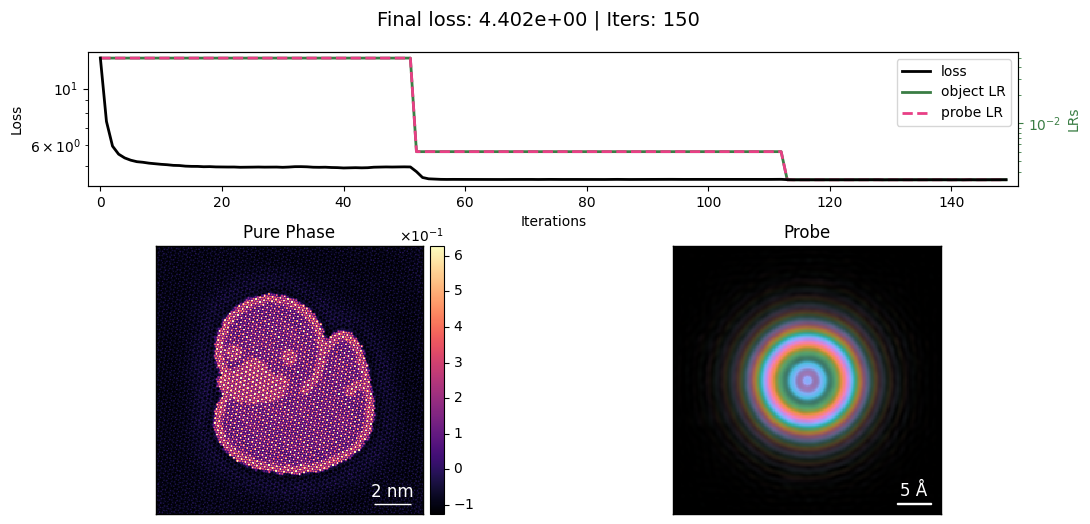

In [4]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(com_fit_function="constant", plot_rotation=False, plot_com=False)

ptycho_pix = Ptychography.from_models(
    dset=pdset,
    obj_model=ObjectPixelated.from_uniform(obj_type="pure_phase", num_slices=1),
    probe_model=ProbePixelated.from_params(probe_params=probe_params),
    detector_model=detector_model,
    rng=42,
)
ptycho_pix.preprocess(obj_padding_px=(32, 32))
ptycho_pix.reconstruct(
    num_iters=150,
    reset=True,
    optimizer_params={"object": OptimizerParams.Adam(lr=5e-2), "probe": OptimizerParams.Adam(lr=5e-2)},
    scheduler_params={"object": SchedulerParams.Plateau(factor=0.1), "probe": SchedulerParams.Plateau(factor=0.1)},
    batch_size=BATCH_SIZE,
    device="gpu",
).visualize()

## Build the INR (warm-started, pretrained once)
Every run below uses `reconstruct(reset=True)`, which reloads these pretrained weights + the
warm-started probe, so each loss starts from the identical point.

Iter 300/300, Loss: 4.552e-04: 100%|██████████| 300/300 [00:12<00:00, 24.70it/s]


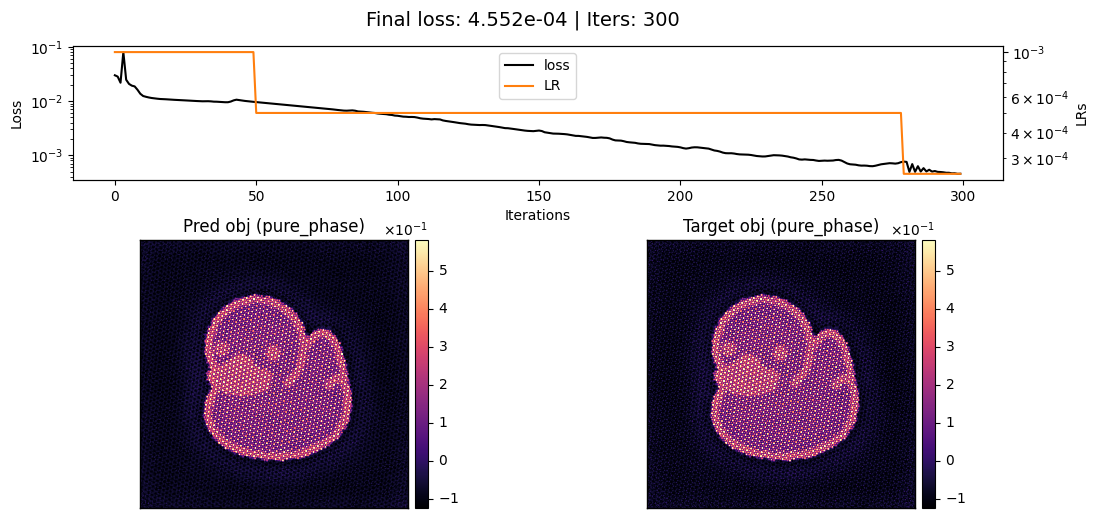

implicit object: True


In [5]:
obj_model_inr = ObjectINR.from_pixelated(
    pixelated=ptycho_pix.obj_model,
    first_omega_0=20,
    hidden_omega_0=20,
    hidden_features=256,
)
probe_model_inr = ProbePixelated.from_array(
    probe_array=ptycho_pix.probe,
    num_probes=1,
    probe_params=probe_params,
)
obj_model_inr.pretrain(
    num_iters=300,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)

ptycho_inr = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_inr,
    probe_model=probe_model_inr,
    detector_model=detector_model,
    device=config.get("device"),
    rng=42,
)
ptycho_inr.preprocess(obj_padding_px=(32, 32))
print("implicit object:", ptycho_inr.dset.implicit_object)

## Helpers

In [6]:
def run_inr(label, loss_type="l2_amplitude", lr_obj=1e-3, lr_probe=1e-3, num_iters=150):
    """Reconstruct from the pretrained INR state with a given loss; return (label, losses, mse, img)."""
    opt = {"object": OptimizerParams.Adam(lr=lr_obj), "probe": OptimizerParams.Adam(lr=lr_probe)}
    sched = {"object": SchedulerParams.CosineAnnealing(), "probe": SchedulerParams.CosineAnnealing()}
    ptycho_inr.reconstruct(
        num_iters=num_iters, reset=True, optimizer_params=opt, scheduler_params=sched,
        batch_size=BATCH_SIZE, device=DEVICES, loss_type=loss_type,
    )
    losses = np.array(ptycho_inr._iter_losses)
    mse = float(np.mean((ptycho_inr.obj_cropped - good_recon) ** 2))
    print(f"{label:24s} final loss={losses[-1]:.3e}  MSE vs good_recon={mse:.3e}")
    return label, losses, mse, ptycho_inr.obj_cropped.sum(0).copy()


def compare(results, title="Data loss"):
    """Per-config loss curves (normalized to iter 0) + a final-MSE bar chart."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for label, losses, mse, _ in results:
        axes[0].semilogy(losses / losses[0], label=label)
    axes[0].set(xlabel="iteration", ylabel="loss / loss[0]", title=f"{title}: convergence")
    axes[0].legend(fontsize=8)
    axes[1].bar(range(len(results)), [r[2] for r in results])
    axes[1].set_xticks(range(len(results)))
    axes[1].set_xticklabels([r[0] for r in results], rotation=30, ha="right", fontsize=8)
    axes[1].set(ylabel="MSE vs good_recon", title=f"{title}: final quality")
    plt.tight_layout()
    plt.show()

## Compare losses
Loss *values* aren't comparable across criteria — judge by the **MSE bar chart** (same metric for
all). `s3im_amplitude` is `MSE + lambda * (1 - S3IM)`; tune `lambda_s3im` / `repeats` via an
`AmplitudeS3IM(...)` instance.

Iter 150/150, Loss: 4.432e+00: 100%|██████████| 150/150 [02:15<00:00,  1.11it/s]


L2                       final loss=4.432e+00  MSE vs good_recon=1.483e-03


Iter 150/150, Loss: 6.807e+00: 100%|██████████| 150/150 [02:15<00:00,  1.11it/s]


L1                       final loss=6.807e+00  MSE vs good_recon=1.463e-03


Iter 150/150, Loss: 2.056e+00: 100%|██████████| 150/150 [02:15<00:00,  1.11it/s]


...

smooth-L1 (beta=0.1)     final loss=5.417e+00  MSE vs good_recon=1.032e-03


Iter 150/150, Loss: 1.319e-07: 100%|██████████| 150/150 [02:25<00:00,  1.03it/s]


S3IM (lambda=1)          final loss=1.319e-07  MSE vs good_recon=8.947e-04


Iter 150/150, Loss: 9.314e-08: 100%|██████████| 150/150 [02:25<00:00,  1.03it/s]


S3IM (lambda=0.2)        final loss=9.314e-08  MSE vs good_recon=7.193e-04


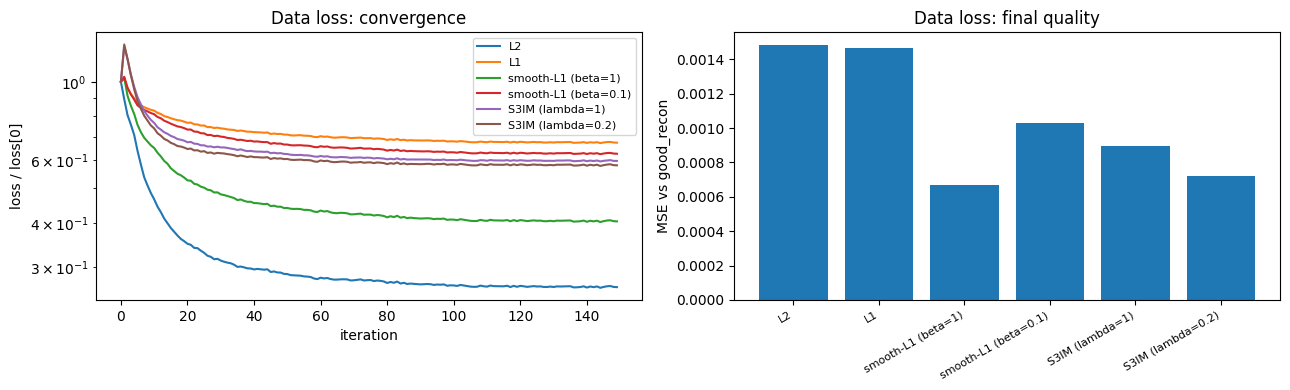

In [7]:
results = []
results.append(run_inr("L2", "l2_amplitude"))
results.append(run_inr("L1", "l1_amplitude"))
results.append(run_inr("smooth-L1 (beta=1)", "smooth_l1_amplitude"))
results.append(run_inr("smooth-L1 (beta=0.1)", AmplitudeSmoothL1(beta=0.1)))
results.append(run_inr("S3IM (lambda=1)", "s3im_amplitude"))
results.append(run_inr("S3IM (lambda=0.2)", AmplitudeS3IM(lambda_s3im=0.2)))
compare(results)

## Best result vs reference

Best: smooth-L1 (beta=1)  (MSE=6.675e-04)


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'reference (good_recon)'}>,
        <Axes: title={'center': 'zoom 1'}>,
        <Axes: title={'center': 'zoom 2'}>], dtype=object))

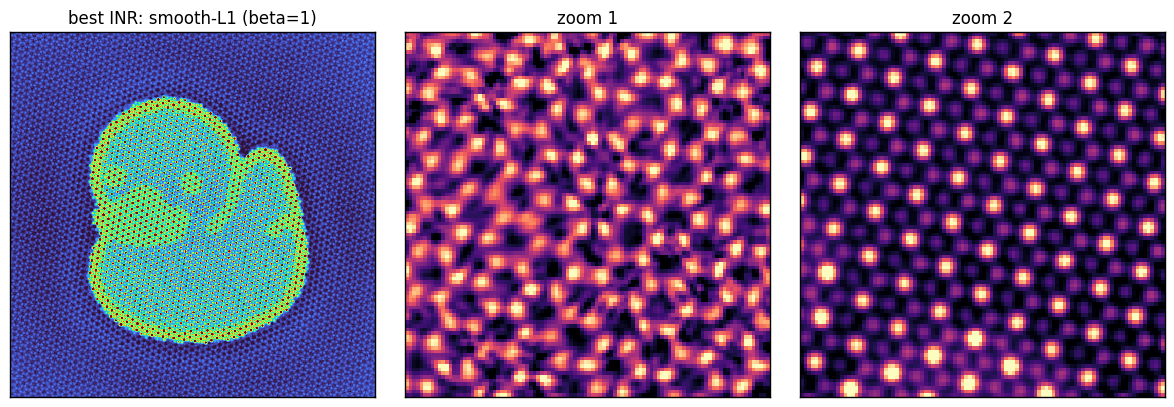

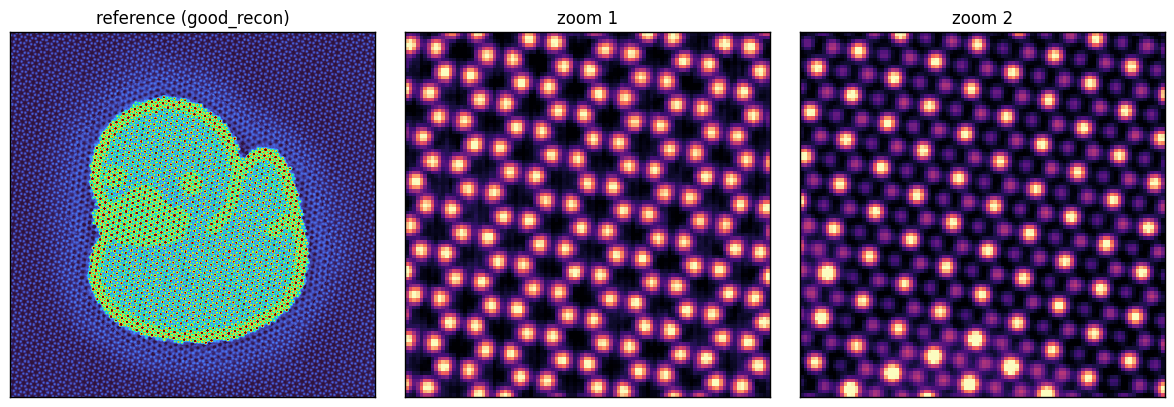

In [8]:
best = min(results, key=lambda r: r[2])
print(f"Best: {best[0]}  (MSE={best[2]:.3e})")
show_2d([best[3], best[3][r1], best[3][r2]], cmap=("turbo", "magma", "magma"),
        title=[f"best INR: {best[0]}", "zoom 1", "zoom 2"])
gr = good_recon.sum(0)
show_2d([gr, gr[r1], gr[r2]], cmap=("turbo", "magma", "magma"),
        title=["reference (good_recon)", "zoom 1", "zoom 2"])